# Model comparison - F1 metric

Leave-one-athlete-out CV for all three methods.  
Reports:
- F1 per class + macro (mean ± std across folds)
- Aggregate normalised confusion matrices
- Timing error per event type (ms and frames)

**Run `stage_xgb_tune.py` first** to get tuned XGBoost params.  
Falls back to default params if the results file is absent.

**TCN** metrics are loaded from the stage 4 LOAO JSON (set `TCN_LOAO_TRIAL_ID` below).  
Set to `None` to skip TCN in the comparison.

In [32]:
import joblib
import json
import os


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from experiments.gait_detection.config import ExperimentConfig
from src.gait.detection.detectors import KinematicDetector
from src.gait.detection.metrics import (
    per_class_f1, confusion_matrix,
)
from src.gait.detection.postprocess import (
    min_duration_filter,
    majority_vote_filter,
    smooth_probs_argmax,
)
from src.gait.gait_data.dataset import load_dataset, train_test_split
from src.gait.image.dataset import load_image_dataset

xgb_params_path    = "data/output/gait/pose_data/stage3/best_params.json"
IMG_XGB_MODEL_PATH = "data/output/gait/image/stage1/checkpoints/xgboost_best.pkl"


TCN_LOAO_TRIAL_ID = 78
TCN_LOAO_DIR      = "data/output/gait/pose_data/stage4/results"

TCN_MANIFEST     = "data/output/gait/pose_data/stage6/manifest.json"
IMG_TCN_MANIFEST = "data/output/gait/image/stage6/manifest.json"
RESNET_MANIFEST  = "data/output/gait/image/resnet/infer/manifest.json"

POSTPROCESSING = {
    "kinematic": {"method": "min_duration_filter",  "window": 3},
    "xgboost":   {"method": "smooth_probs_argmax",  "window": 3},
    "img_xgb":   {"method": "smooth_probs_argmax",  "window": 3},
    "tcn":       {"method": "smooth_probs_argmax",  "window": 3},
    "img_tcn":   {"method": "smooth_probs_argmax",  "window": 3},
    "resnet":    {"method": "smooth_probs_argmax",  "window": 3},
}


def apply_pp(model_key: str, data: np.ndarray) -> np.ndarray:
    cfg_pp = POSTPROCESSING[model_key]
    method, window = cfg_pp["method"], cfg_pp["window"]
    if method == "min_duration_filter":
        return min_duration_filter(data, min_frames=window)
    if method == "majority_vote_filter":
        return majority_vote_filter(data, window=window)
    if method == "smooth_probs_argmax":
        return smooth_probs_argmax(data, window=window)
    raise ValueError(f"Unknown postprocessing method: {method!r}")

In [33]:
cfg = ExperimentConfig()
all_records = load_dataset(cfg.annotations_csv, fps=cfg.fps)
train_records, test_records, TEST_ATHLETES = train_test_split(all_records)

athletes = sorted({r.athlete for r in train_records})
n_folds  = len(athletes)
print(f"{len(all_records)} total videos, {len(train_records)} train ({n_folds} athletes), "
      f"{len(test_records)} test")
print(f"Test athletes: {TEST_ATHLETES}")

IMG_FEATURES_DIR = "data/output/gait/image_features"
VIDEO_INPUT_DIR  = "data/input/optojump"

img_records_by_path = {}
img_all = load_image_dataset(cfg.annotations_csv, IMG_FEATURES_DIR, VIDEO_INPUT_DIR)
img_records_by_path = {r.video_path: r for r in img_all}
print(f"{len(img_all)} image records loaded")

178 total videos, 162 train (20 athletes), 16 test
Test athletes: ['antoni_pejtler', 'milosz_jarzab']
178 image records loaded


In [34]:
with open(xgb_params_path) as f:
    xgb_meta = json.load(f)
XGB_PARAMS = xgb_meta["best_params"]
print(f"Loaded tuned params  (val macro F1 = {xgb_meta['best_val_macro_f1']:.3f})")
print(f"feature_idx from tuning: {xgb_meta['feature_idx']}")


Loaded tuned params  (val macro F1 = 0.853)
feature_idx from tuning: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [35]:
def flatten(records, feature_idx=None):
    X, y = [], []
    for r in records:
        feats = r.features if feature_idx is None else r.features[:, feature_idx]
        X.append(feats)
        y.append(r.labels)
    return np.vstack(X), np.concatenate(y)


def eval_fold(preds_per_rec, val_records, cfg):
    y_true = np.concatenate([rec.labels for rec in val_records])
    y_pred = np.concatenate(preds_per_rec)

    return {
        "f1": per_class_f1(y_true, y_pred, cfg.n_classes, cfg.class_names),
        "confusion_matrix": confusion_matrix(y_true, y_pred, cfg.n_classes),
    }

In [36]:
# ── Train XGBoost on all train_records ───────────────────────────────────────
XGB_NEEDS_PROBA = POSTPROCESSING["xgboost"]["method"] == "smooth_probs_argmax"

X_all_train, y_all_train = flatten(train_records, cfg.feature_idx)
clf_final = xgb.XGBClassifier(
    **XGB_PARAMS,
    eval_metric="mlogloss", tree_method="hist", device="cpu", verbosity=0,
)
clf_final.fit(X_all_train, y_all_train)

# ── Evaluate on train set (in-sample) ────────────────────────────────────────
kinematic = KinematicDetector()

kin_train_preds = [apply_pp("kinematic", kinematic.predict(r.features, cfg.fps))
                   for r in train_records]
kin_train = eval_fold(kin_train_preds, train_records, cfg)

xgb_train_preds = []
for r in train_records:
    feats = r.features if cfg.feature_idx is None else r.features[:, cfg.feature_idx]
    if XGB_NEEDS_PROBA:
        xgb_train_preds.append(apply_pp("xgboost", clf_final.predict_proba(feats)))
    else:
        xgb_train_preds.append(apply_pp("xgboost", clf_final.predict(feats).astype(np.int64)))
xgb_train = eval_fold(xgb_train_preds, train_records, cfg)

In [37]:
img_xgb_clf          = None
img_xgb_train_result = None

if os.path.exists(IMG_XGB_MODEL_PATH) and img_records_by_path:
    img_xgb_clf = joblib.load(IMG_XGB_MODEL_PATH)

    img_xgb_tr_preds, img_xgb_tr_recs = [], []
    for r in train_records:
        img_rec = img_records_by_path.get(r.video_path)
        if img_rec is None:
            continue
        img_xgb_tr_preds.append(apply_pp("img_xgb", img_xgb_clf.predict_proba(img_rec.features)))
        img_xgb_tr_recs.append(img_rec)

    img_xgb_train_result = eval_fold(img_xgb_tr_preds, img_xgb_tr_recs, cfg)

In [38]:
def load_manifest_preds(manifest_path, records, pp_key, needs_proba, split_name='train', img_lookup=None):

    with open(manifest_path) as f:
        m = json.load(f)
    idx = {r["video_path"]: r for r in m["records"]}

    preds, final_recs = [], []
    for rec in records:
        entry = idx.get(rec.video_path)
        if not entry or entry["split"] != split_name:
            continue

        # Use image records if it's an image-based model
        target_rec = img_lookup.get(rec.video_path) if img_lookup else rec
        if target_rec is None: continue

        probs = np.load(entry["probs_path"])
        input_data = probs if needs_proba else probs.argmax(axis=1).astype(np.int64)

        preds.append(apply_pp(pp_key, input_data))
        final_recs.append(target_rec)

    return eval_fold(preds, final_recs, cfg), m, preds


def get_xgb_preds(clf, records, needs_pb, img_lookup=None):
    preds = []
    for r in records:
        target = img_lookup.get(r.video_path) if img_lookup else r
        if target is None: continue
        feats = target.features if cfg.feature_idx is None else target.features[:, cfg.feature_idx]
        p = clf.predict_proba(feats) if needs_pb else clf.predict(feats).astype(np.int64)
        preds.append(apply_pp("xgboost", p))
    return preds

In [39]:
classes_all = cfg.class_names + ["macro"]

def _pp_label(key):
    pp = POSTPROCESSING[key]
    name = pp["method"].replace("_filter", "").replace("_argmax", "")
    return f"{name}"#  w={pp['window']}"

def _result_f1(result):
    return {c: [result["f1"][c]] for c in classes_all}

TCN_NEEDS_PROBA     = POSTPROCESSING["tcn"]["method"]     == "smooth_probs_argmax"
IMG_TCN_NEEDS_PROBA = POSTPROCESSING["img_tcn"]["method"] == "smooth_probs_argmax"
RESNET_NEEDS_PROBA  = POSTPROCESSING["resnet"]["method"]  == "smooth_probs_argmax"

In [40]:
neural_specs = [
    {"key": "tcn",     "path": TCN_MANIFEST,     "needs_pb": TCN_NEEDS_PROBA,     "img": False},
    {"key": "img_tcn", "path": IMG_TCN_MANIFEST, "needs_pb": IMG_TCN_NEEDS_PROBA, "img": True},
    {"key": "resnet",  "path": RESNET_MANIFEST,  "needs_pb": RESNET_NEEDS_PROBA,  "img": True},
]

results = {}
for spec in neural_specs:
    res, m, _ = load_manifest_preds(
        spec["path"], train_records, spec["key"], spec["needs_pb"],
        split_name="train",
        img_lookup=img_records_by_path if spec["img"] else None
    )
    results[spec["key"]] = {"res": res, "m": m}

METHODS_TRAIN = [
    {"label": f"Kinematic [{_pp_label('kinematic')}]", "color": "C0", "f1": _result_f1(kin_train), "cm": kin_train["confusion_matrix"]},
    {"label": f"XGBoost [{_pp_label('xgboost')}]", "color": "C1", "f1": _result_f1(xgb_train), "cm": xgb_train["confusion_matrix"]},
]

for key, color in [("tcn", "C2"), ("img_tcn", "C3"), ("resnet", "C4")]:
    if key in results:
        label = f"{key} (trial #{results[key]['m'].get('trial_id', 'N/A')})"
        METHODS_TRAIN.append({
            "label": f"{label} [{_pp_label(key)}]", "color": color,
            "f1": _result_f1(results[key]["res"]), "cm": results[key]["res"]["confusion_matrix"]
        })

In [41]:
kin_test = eval_fold([apply_pp("kinematic", kinematic.predict(r.features, cfg.fps)) for r in test_records], test_records, cfg)
xgb_test = eval_fold(get_xgb_preds(clf_final, test_records, XGB_NEEDS_PROBA), test_records, cfg)

METHODS_TEST = [
    {"label": f"Kinematic [{_pp_label('kinematic')}]", "color": "C0", "f1": _result_f1(kin_test), "cm": kin_test["confusion_matrix"]},
    {"label": f"XGBoost [{_pp_label('xgboost')}]", "color": "C1", "f1": _result_f1(xgb_test), "cm": xgb_test["confusion_matrix"]},
]

---
## Train set — in-sample evaluation

In [42]:
def plot_f1_bars(methods, title, ax=None):
    n_methods = len(methods)
    w = 0.7 / n_methods
    x = np.arange(len(classes_all))
    fig, ax = plt.subplots(figsize=(11, 5)) if ax is None else (None, ax)
    for i, m in enumerate(methods):
        means = [np.nanmean(m["f1"][c]) for c in classes_all]
        stds  = [np.nanstd(m["f1"][c])  for c in classes_all]
        offset = (i - n_methods / 2 + 0.5) * w
        bars = ax.bar(x + offset, means, w, yerr=stds, capsize=4,
                      label=m["label"], color=m["color"], alpha=0.9)
        for bar, val in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels([c.replace("_", "\n") for c in classes_all], fontsize=10)
    ax.set_ylabel("F1 score")
    ax.set_ylim(0, 1.15)
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    if fig:
        plt.tight_layout()
        plt.show()

## Confusion matrices

In [43]:
def plot_confusion_matrices(methods, suptitle):
    labels_short = ["L-stance", "R-stance", "Flight"]
    n = len(methods)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, m in zip(axes, methods):
        cm_arr  = np.array(m["cm"], dtype=float)
        cm_norm = cm_arr / cm_arr.sum(axis=1, keepdims=True)
        sns.heatmap(cm_norm, annot=True, fmt=".2f", ax=ax,
                    xticklabels=labels_short, yticklabels=labels_short,
                    cmap="Blues", vmin=0, vmax=1, cbar=False)
        ax.set_title(f"{m['label']}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
    plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

In [44]:
def f1_table(methods):
    rows = []
    for c in classes_all:
        row = {"Class": c.replace("_", " ")}
        for m in methods:
            mean = np.nanmean(m["f1"][c])
            std  = np.nanstd(m["f1"][c])
            row[f"{m['label']} F1"] = f"{mean:.3f} ± {std:.3f}"
        row[f"Δ (last − first)"] = (
            f"{np.nanmean(methods[-1]['f1'][c]) - np.nanmean(methods[0]['f1'][c]):+.3f}"
        )
        rows.append(row)
    return pd.DataFrame(rows).set_index("Class")


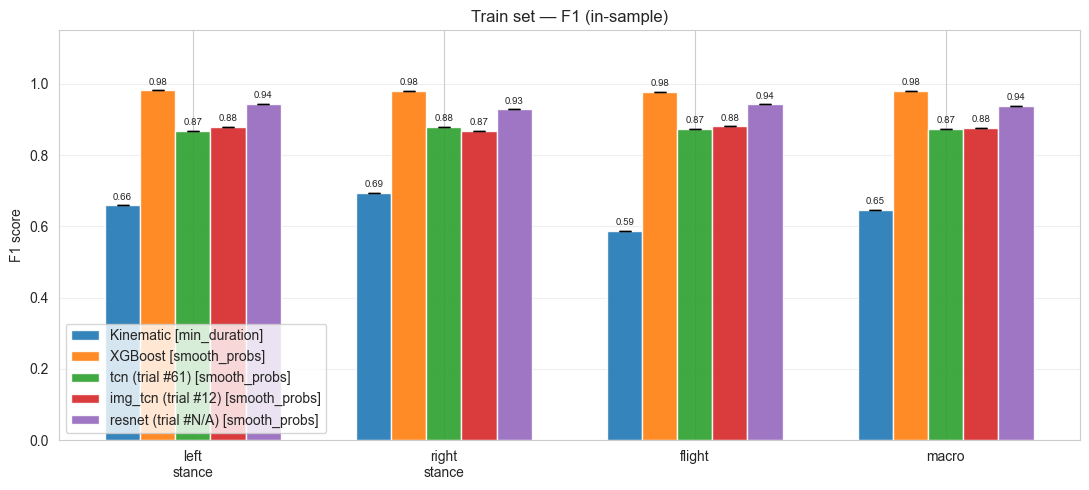

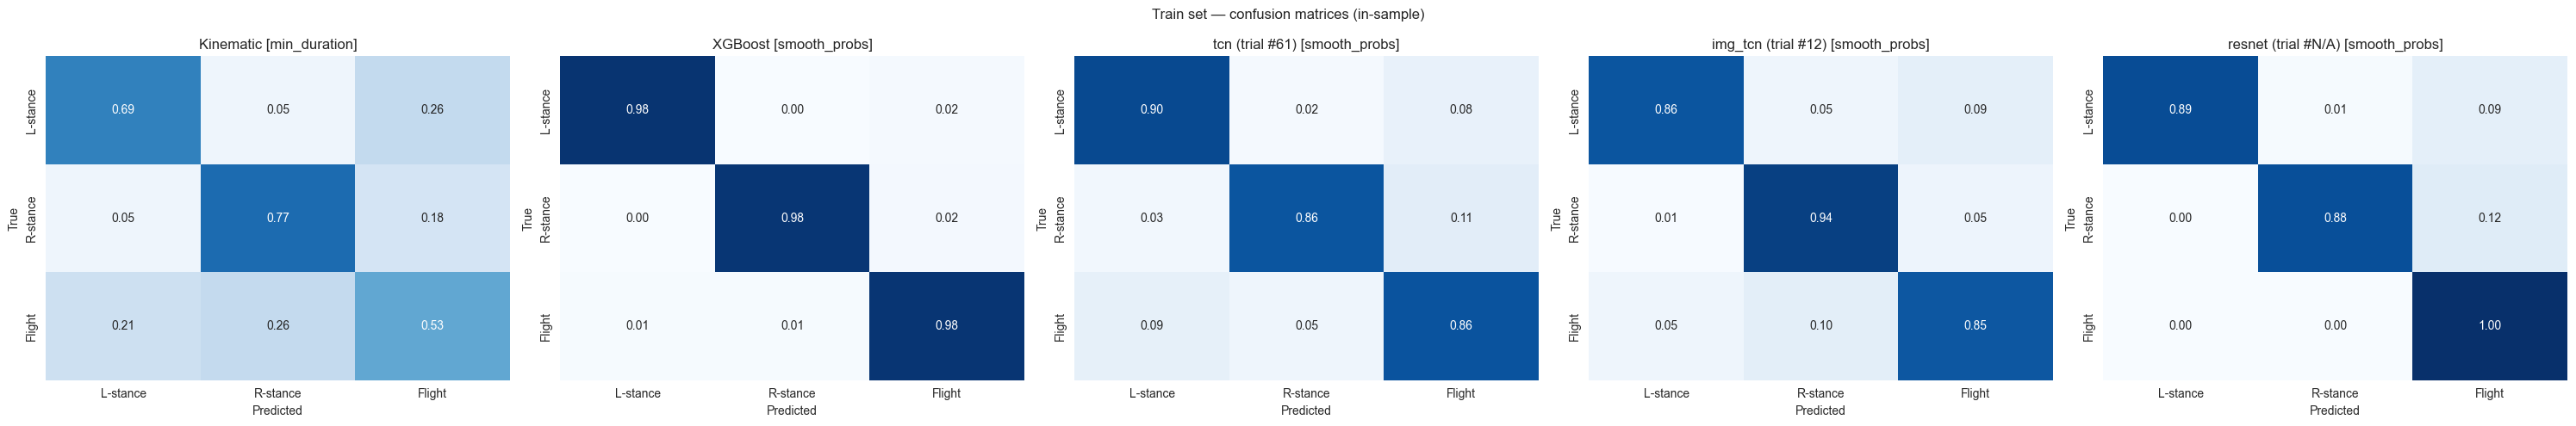

In [45]:
plot_f1_bars(METHODS_TRAIN, "Train set — F1 (in-sample)")
plot_confusion_matrices(METHODS_TRAIN, "Train set — confusion matrices (in-sample)")

---
## Test set — held-out athletes

TCN and XGBoost are evaluated with the model trained on all train athletes.

In [46]:
METHODS_TEST = [
    {"label": f"Kinematic [{_pp_label('kinematic')}]", "color": "C0", "f1": _result_f1(kin_test), "cm": kin_test["confusion_matrix"]},
    {"label": f"XGBoost [{_pp_label('xgboost')}]", "color": "C1", "f1": _result_f1(xgb_test), "cm": xgb_test["confusion_matrix"]},
]

test_specs = [
    {"key": "tcn",     "path": TCN_MANIFEST,     "needs_pb": TCN_NEEDS_PROBA,     "img": False, "color": "C2", "name": "Pose TCN"},
    {"key": "img_tcn", "path": IMG_TCN_MANIFEST, "needs_pb": IMG_TCN_NEEDS_PROBA, "img": True,  "color": "C3", "name": "Image TCN"},
    {"key": "resnet",  "path": RESNET_MANIFEST,  "needs_pb": RESNET_NEEDS_PROBA,  "img": True,  "color": "C4", "name": "ResNet"},
]

for spec in test_specs:
    res, m, _ = load_manifest_preds(
        spec["path"],
        test_records,
        spec["key"],
        spec["needs_pb"],
        split_name="test",
        img_lookup=img_records_by_path if spec["img"] else None
    )

    trial_str = f" (trial #{m['trial_id']})" if "trial_id" in m else ""
    METHODS_TEST.append({
        "label": f"{spec['name']}{trial_str}  [{_pp_label(spec['key'])}]",
        "color": spec["color"],
        "f1": _result_f1(res),
        "cm": res["confusion_matrix"],
    })

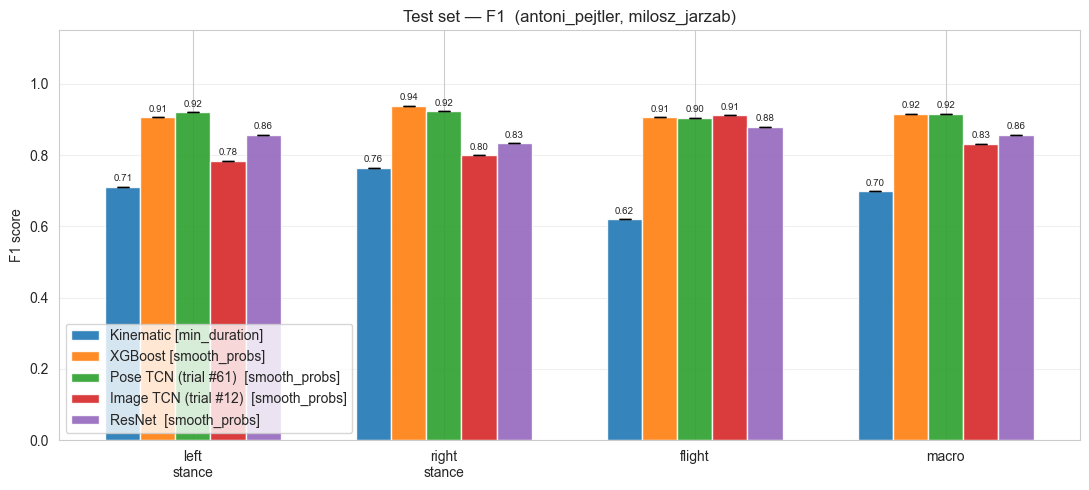

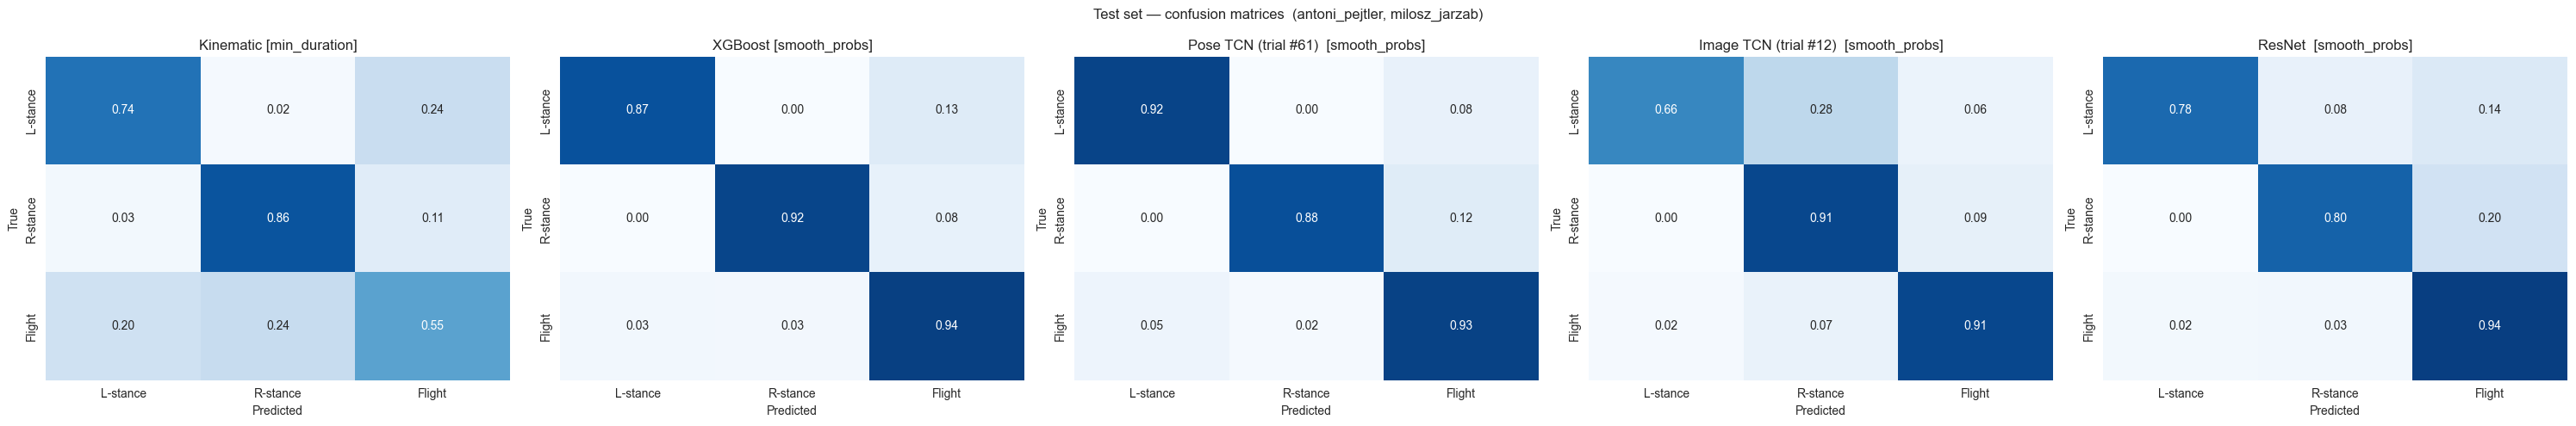

In [47]:
plot_f1_bars(METHODS_TEST, f"Test set — F1  ({', '.join(TEST_ATHLETES)})")
plot_confusion_matrices(METHODS_TEST, f"Test set — confusion matrices  ({', '.join(TEST_ATHLETES)})")